# File to DO EDA on the Intensities dataset 

### Constants

In [39]:
from enum import Enum

DATASET_PATH = "data/processed/intensities_t1.csv"


class T1ModelSchema(str, Enum):
    """Enumeration of active features and target used in Tier 1 model training.

    Predictors (X):
        MAG: Preferred earthquake magnitude (Mw).
        MMI: Observed Modified Mercalli Intensity shaking threshold.
        DEPTH_S: Focal depth relative to DEM ground surface (km).
        REGIME: Tectonic regime classification (e.g., subduction, crustal).

    Target (y):
        RHYPO: 3D straight-line hypocentral distance (km).
    """

    MAG = "magnitude"
    MMI = "mmi"
    DEPTH_S = "depth_surface"
    REGIME = "regime"
    RHYPO = "r_hypo"

ALL_FEATURES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.REGIME.value]
ALL_PROPERTIES =ALL_FEATURES + [T1ModelSchema.RHYPO.value]
NUMERIC_PROPERTIES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.RHYPO.value]

class MetadataSchema(str, Enum):
    """Enumeration of passive metadata and auxiliary spatial features.

    Used for GroupKFold splitting keys, spatial indexing, and coordinate references.
    These are excluded from the direct model input vector.
    """
    ID = "usgs_id"
    LONGITUDE = "longitude"
    LATITUDE = "latitude"
    DEPTH_F = "depth_from_sea"
    ELEVATION = "elevation"

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATASET_PATH)

# Basic Information about the dataset
- shape of the dataset
- information about the dataset
- describe the dataset
- duplicated rows in the dataset
- check for null values in the dataset

In [41]:
df.shape

(672040, 10)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672040 entries, 0 to 672039
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   usgs_id         672040 non-null  str    
 1   longitude       672040 non-null  float64
 2   latitude        672040 non-null  float64
 3   magnitude       672040 non-null  float64
 4   mmi             672040 non-null  float64
 5   depth_from_sea  672040 non-null  float64
 6   regime          672040 non-null  str    
 7   r_hypo          672040 non-null  float64
 8   elevation       672040 non-null  float64
 9   depth_surface   672040 non-null  float64
dtypes: float64(8), str(2)
memory usage: 51.3 MB


In [43]:
df.describe()

,longitude,latitude,magnitude,mmi,depth_from_sea,r_hypo,elevation,depth_surface
count,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000
mean,-118.650033,36.704509,4.416974,2.871118,10.772887,88.564560,0.637484,11.412593
std,2.895354,3.778643,1.045155,0.954404,6.620741,97.138831,0.641012,6.495197
min,-126.193600,30.793600,3.000000,1.000000,-3.340000,0.562028,-0.079000,0.000000
25%,-121.610500,33.948500,3.600000,2.200000,7.302000,26.250335,0.087000,8.006000
50%,-118.163300,35.705330,4.190000,2.700000,9.990000,53.610165,0.455000,10.541000
75%,-116.914700,38.168900,4.990000,3.400000,13.051000,117.410800,0.967000,14.038000
max,-105.182000,49.203300,7.300000,9.100000,76.200000,1834.186000,3.428000,78.905000


In [44]:
df.head()

,usgs_id,longitude,latitude,magnitude,mmi,depth_from_sea,regime,r_hypo,elevation,depth_surface
0,nc71729135,-122.7432,38.79267,4.16,5.8,0.477,active,2.129752,1.045,1.522
1,nc72737985,-122.8413,38.82217,5.01,5.8,1.480,active,2.670254,0.606,2.086
2,ci3031111,-116.4370,34.20000,7.30,7.9,-0.097,active,10.555350,1.054,0.957
3,nn00385392,-119.9393,39.52310,5.10,6.7,2.800,subduction,3.029873,1.461,4.261
4,nc72737985,-122.8413,38.82217,5.01,6.1,1.480,active,2.307831,0.606,2.086


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isna().sum()

usgs_id           0
longitude         0
latitude          0
magnitude         0
mmi               0
depth_from_sea    0
regime            0
r_hypo            0
elevation         0
depth_surface     0
dtype: int64

## checking if the MMI values are less than 3,
- since they are also important for the analysis, I will not drop them, but I will keep a note of how many such values are there

In [47]:

print(len(df[df[T1ModelSchema.MMI] < 3]))

376856


In [48]:
def calculate_plot_dimension(count:int)-> tuple[int, int]:
	horizontal = int(np.ceil(np.sqrt(count)))
	vertical = int(np.ceil(count / horizontal))
	if horizontal * vertical < count:
		vertical += 1
	if horizontal < vertical:
		horizontal, vertical = vertical, horizontal
	return (horizontal, vertical)


### Histogram of All Predictors and Target

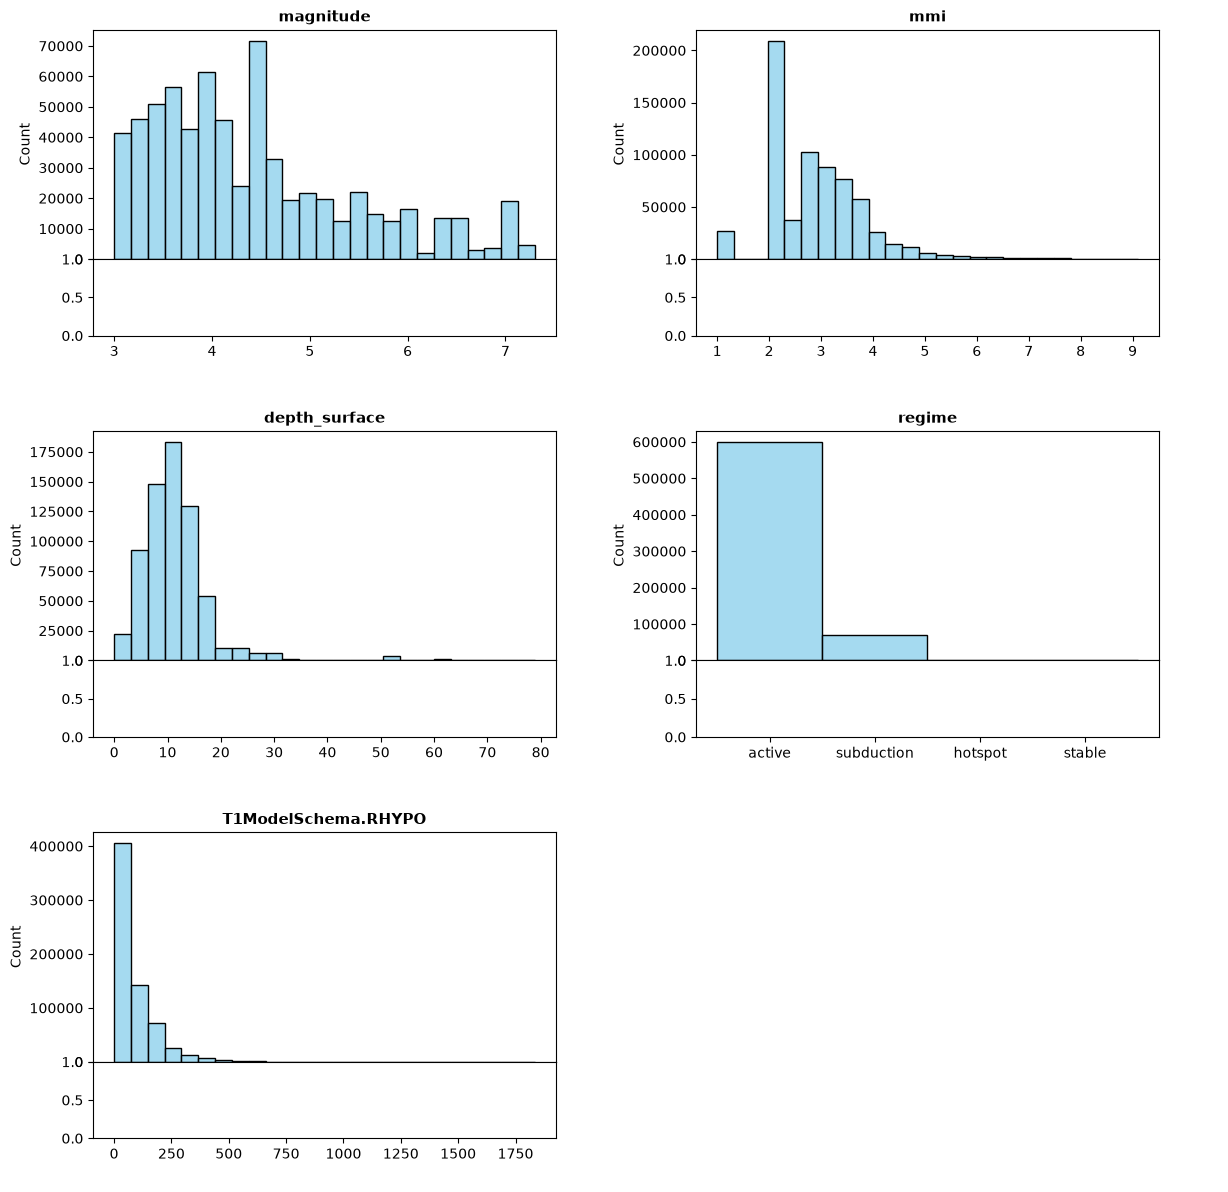

28162

In [49]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
    ax1, ax2 = subfigs[i].subplots(
        2, 1, 
        sharex=True, 
        gridspec_kw={"height_ratios": [3, 1]}
    )
    sns.histplot(
        data=df, 
        x=col, 
        bins=25, 
        color="skyblue",                         
        ax=ax1
    )
    ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax1.set_xlabel("")
    subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### Box plot for all predictors and target variable

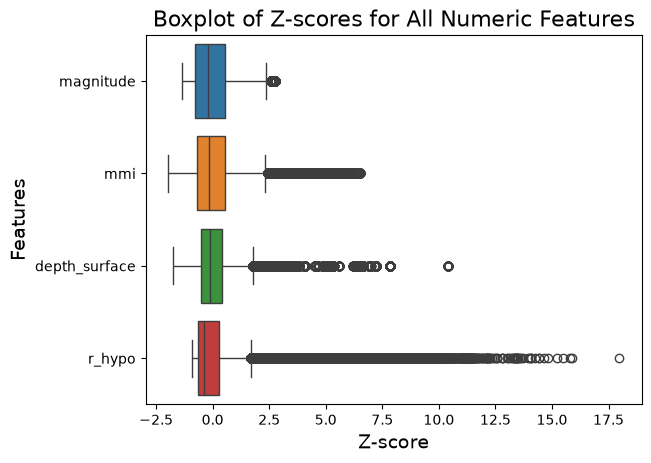

In [50]:
numeric_df = df[ALL_PROPERTIES].select_dtypes(include="number")
z = (numeric_df - numeric_df.mean()) / numeric_df.std()
sns.boxplot(
    data=z,
    orient="h",
)
plt.title("Boxplot of Z-scores for All Numeric Features", fontsize=16)
plt.xlabel("Z-score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

### Combined Figures for Histograms and Boxplots

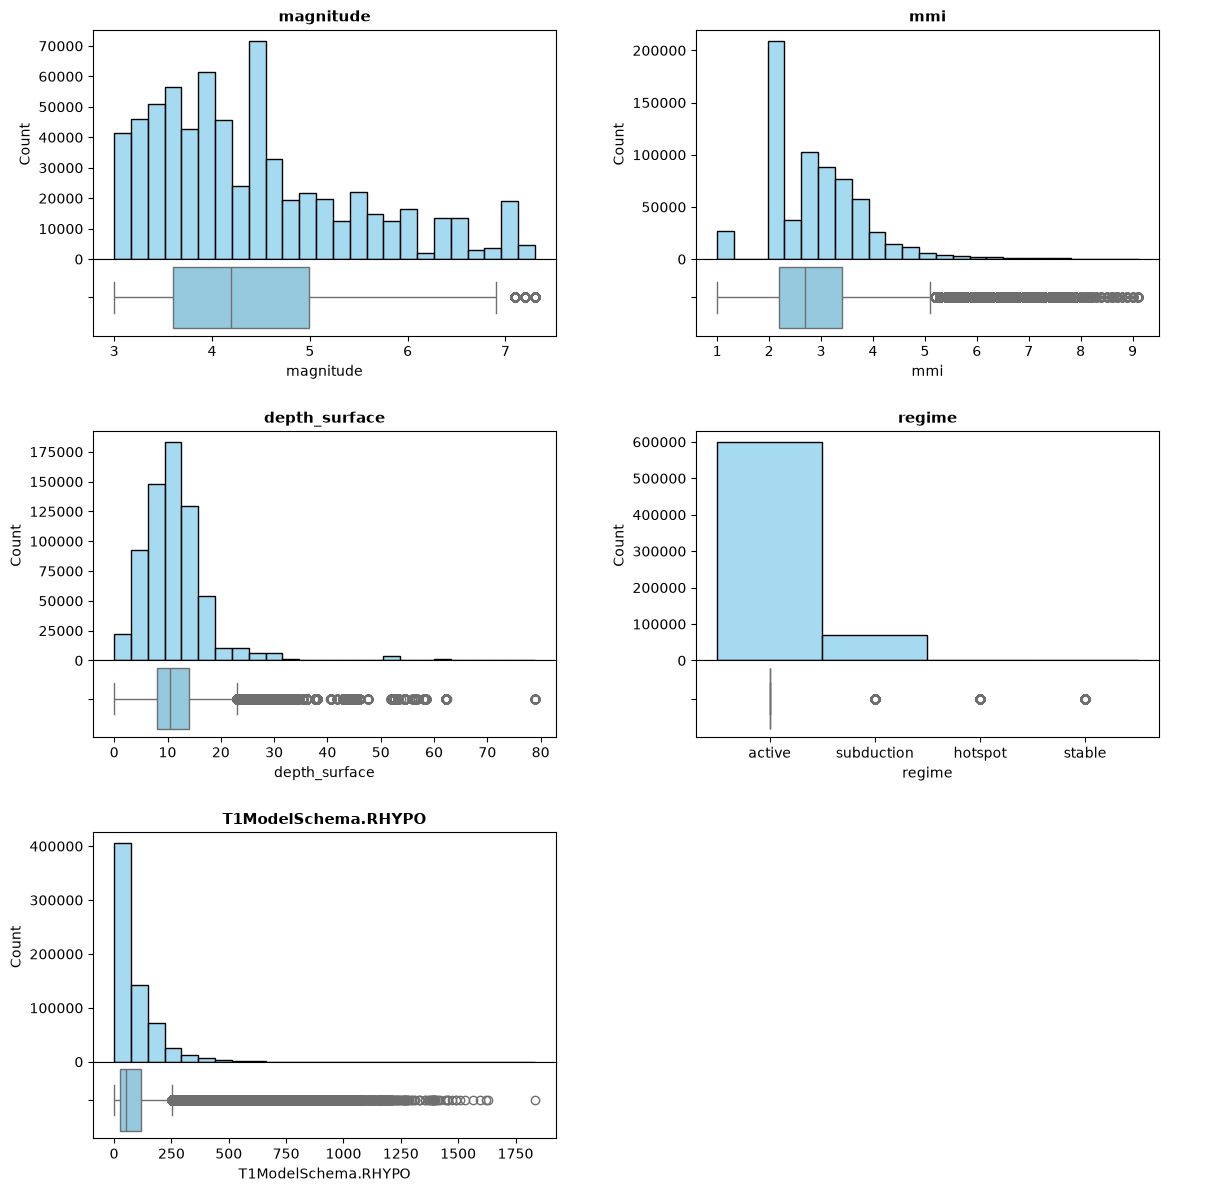

4259

In [51]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
    ax1, ax2 = subfigs[i].subplots(
        2, 1, 
        sharex=True, 
        gridspec_kw={"height_ratios": [3, 1]}
    )
    
    sns.histplot(
        data=df, 
        x=col, 
        bins=25, 
        color="skyblue",                         
        ax=ax1
    )
    
    ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax1.set_xlabel("")
    
    sns.boxplot(data=df, x=col, color="skyblue", ax=ax2)
    subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### HeatMap of Correlation Matrix


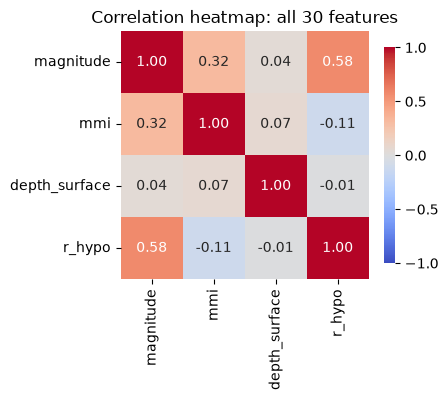

In [52]:
plt.figure(figsize=(4, 4))
numeric_df = df[ALL_PROPERTIES].select_dtypes(include="number")
numeric_labels = numeric_df.columns.tolist()

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, xticklabels=numeric_labels, yticklabels=numeric_labels, 
            cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap: all 30 features")
plt.show()

### Pair Plot of All Numeric Properties

In [53]:
# print("This will take a while to run, please be patient...")
# sns.pairplot(
# 	data=df,
# 	vars=NUMERIC_PROPERTIES,
# 	hue=T1ModelSchema.REGIME.value,
# 	plot_kws={'alpha': 0.7}
# )
# plt.suptitle("Pairplot of Numeric Features", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

### Scatter Plot With Targer

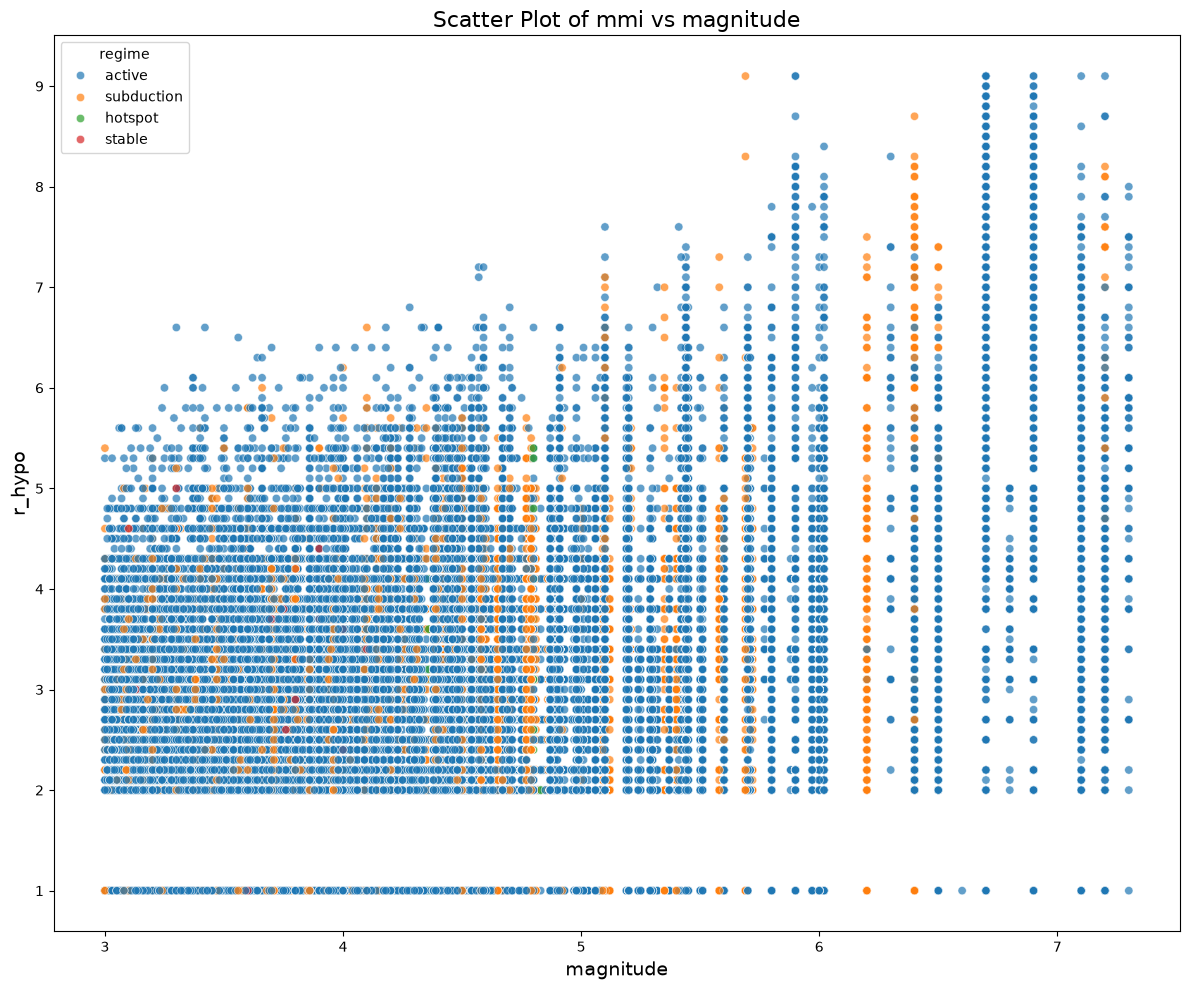

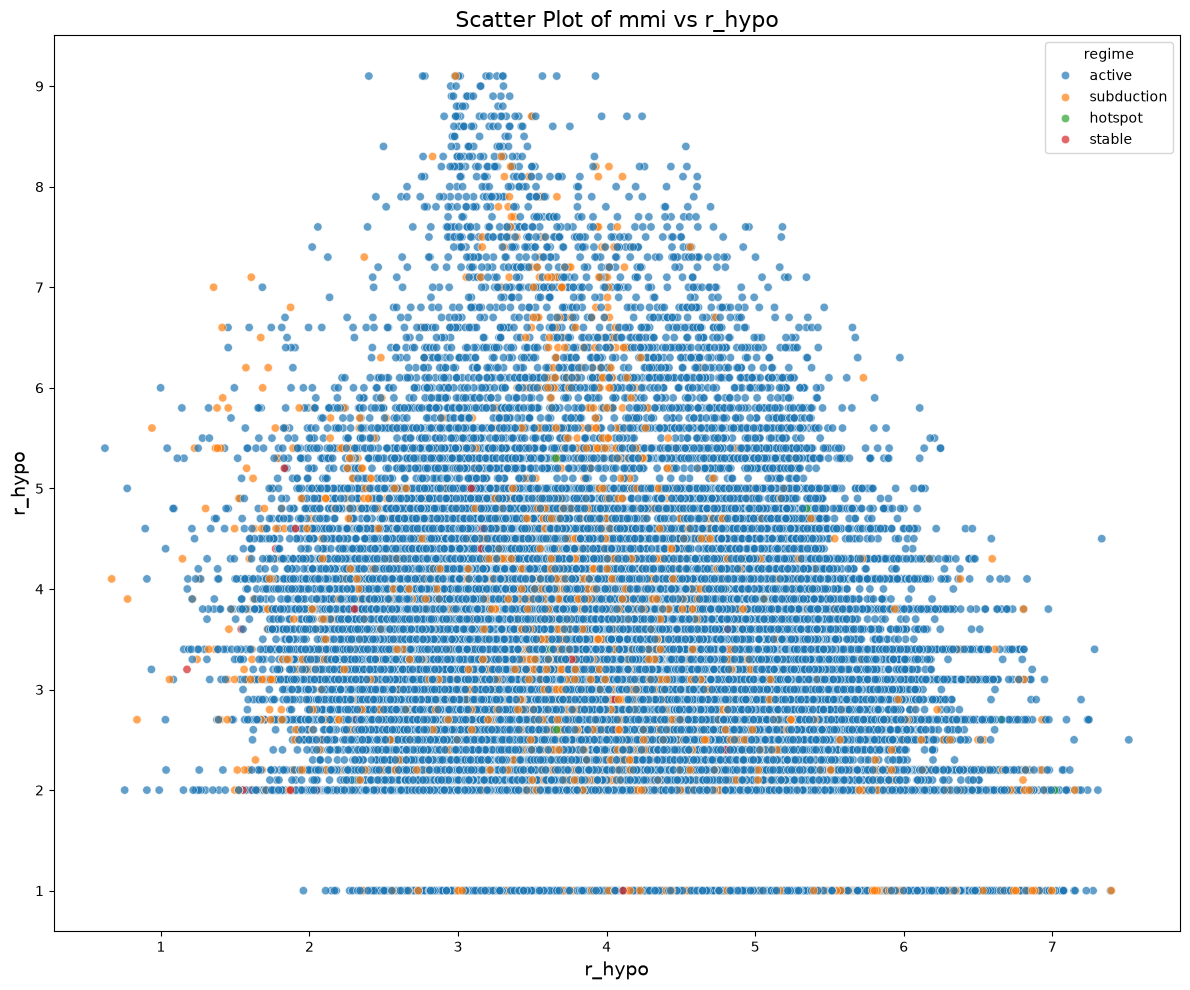

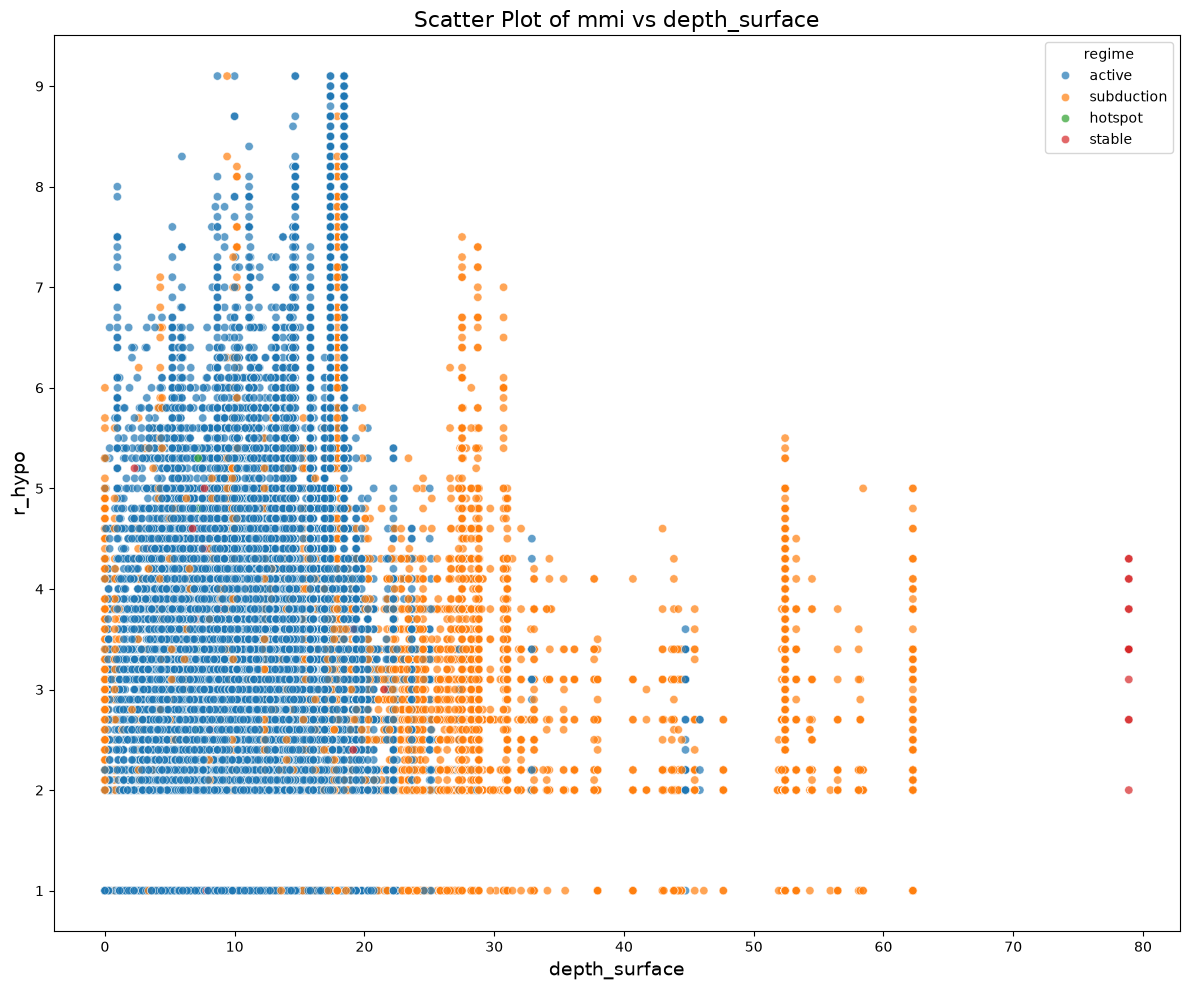

In [54]:
# Scatter Plot With the target variable (RHYPO) on the y-axis and each of the other features on the x-axis
# unquedf = df.drop_duplicates(subset=[MetadataSchema.ID.value])

logged_df = df.sample(frac=0.25, random_state=42)  # Sample 25% of the data for faster plotting
logged_df[T1ModelSchema.RHYPO.value] = np.log(logged_df[T1ModelSchema.RHYPO.value] + 1)



used_feature = [T1ModelSchema.MAG.value, T1ModelSchema.RHYPO.value, T1ModelSchema.DEPTH_S.value]
target_feature = T1ModelSchema.MMI.value
for col in used_feature:
	plt.figure(figsize=(12, 10))
	sns.scatterplot(
		data=logged_df,
		x=col,
		y=target_feature,
		hue=T1ModelSchema.REGIME.value,
		alpha=0.7
	)
	plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
	plt.xlabel(col, fontsize=14)
	plt.ylabel(T1ModelSchema.RHYPO.value, fontsize=14)
	plt.legend(title=T1ModelSchema.REGIME.value)
	plt.tight_layout()
	plt.show()

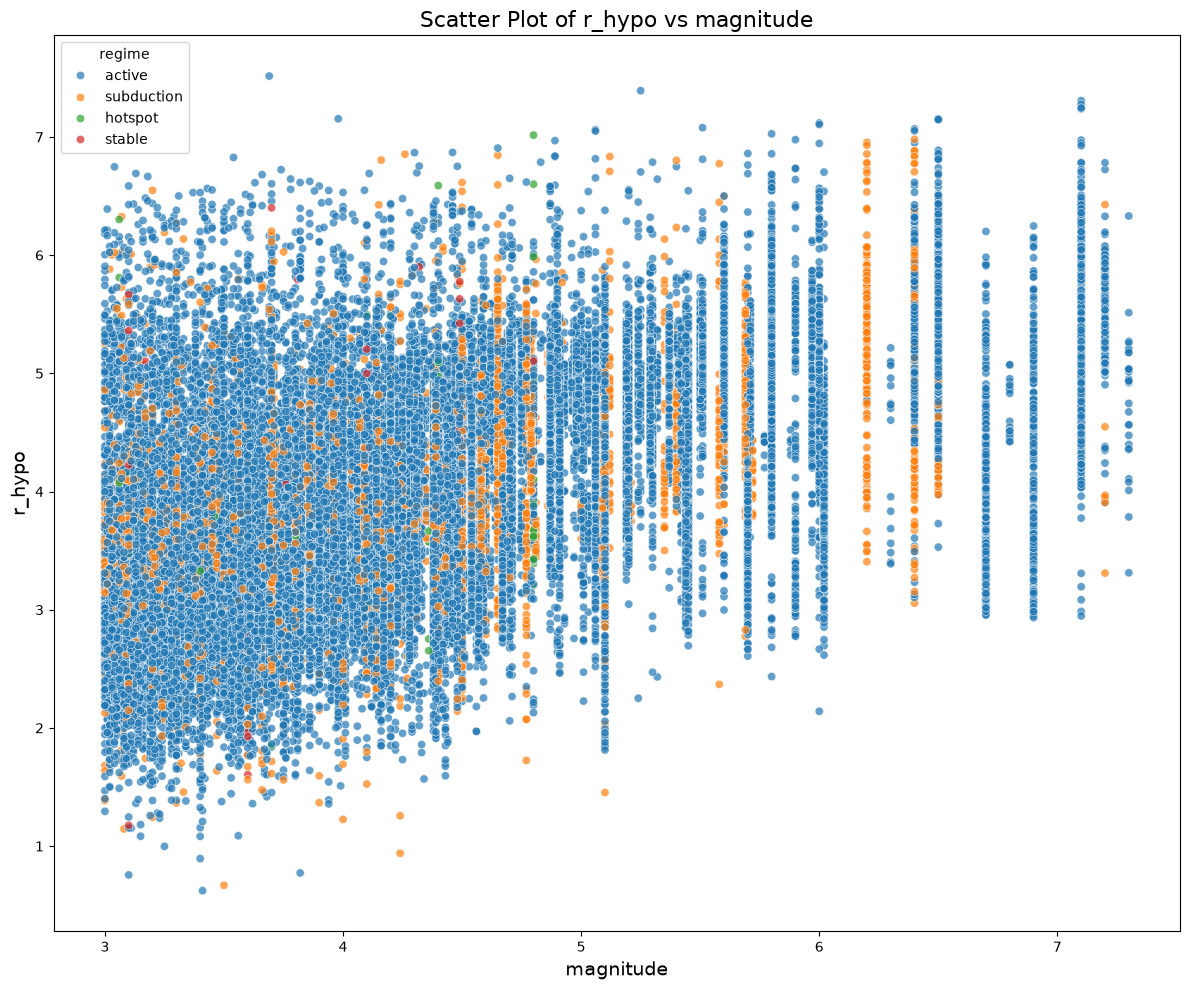

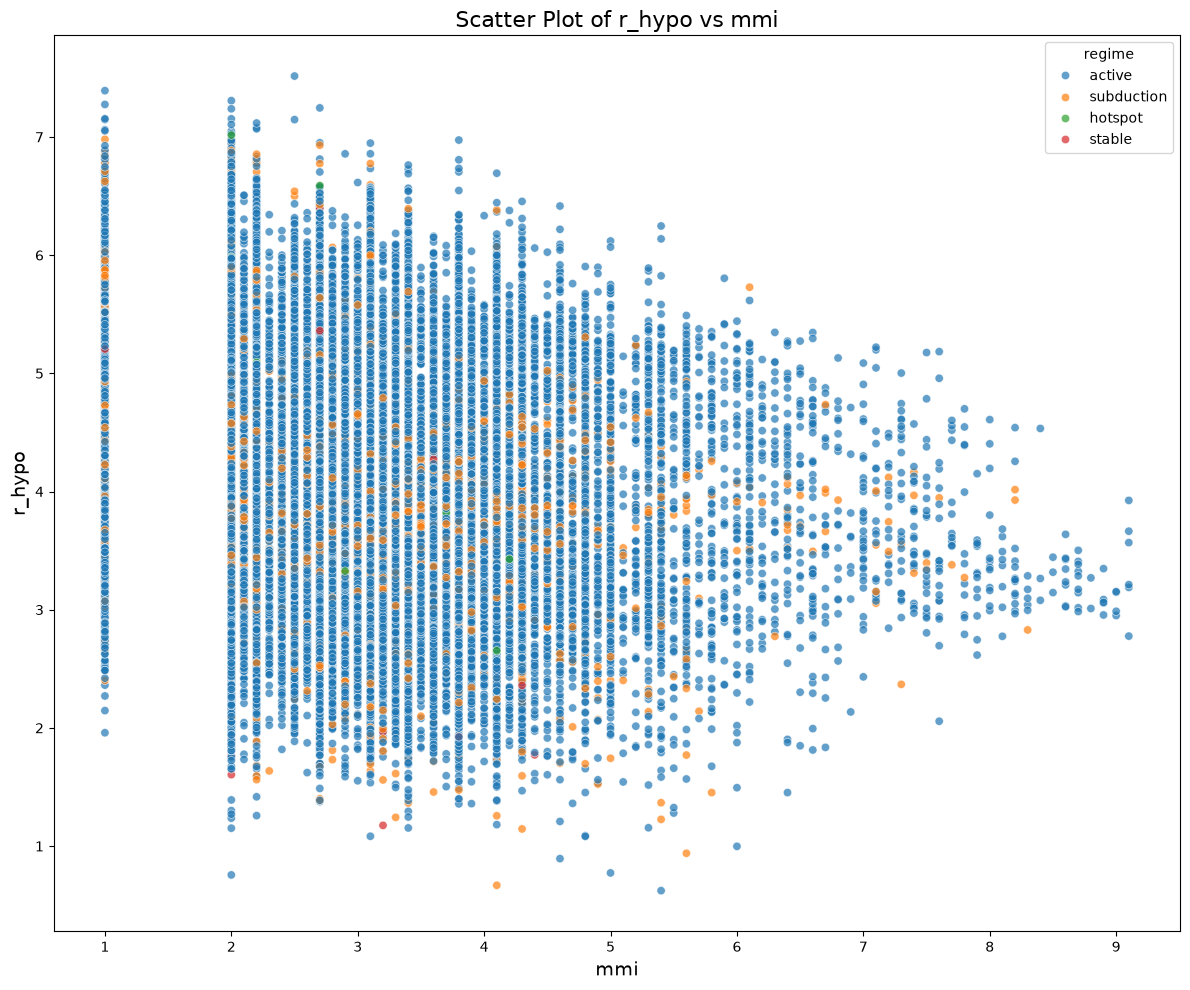

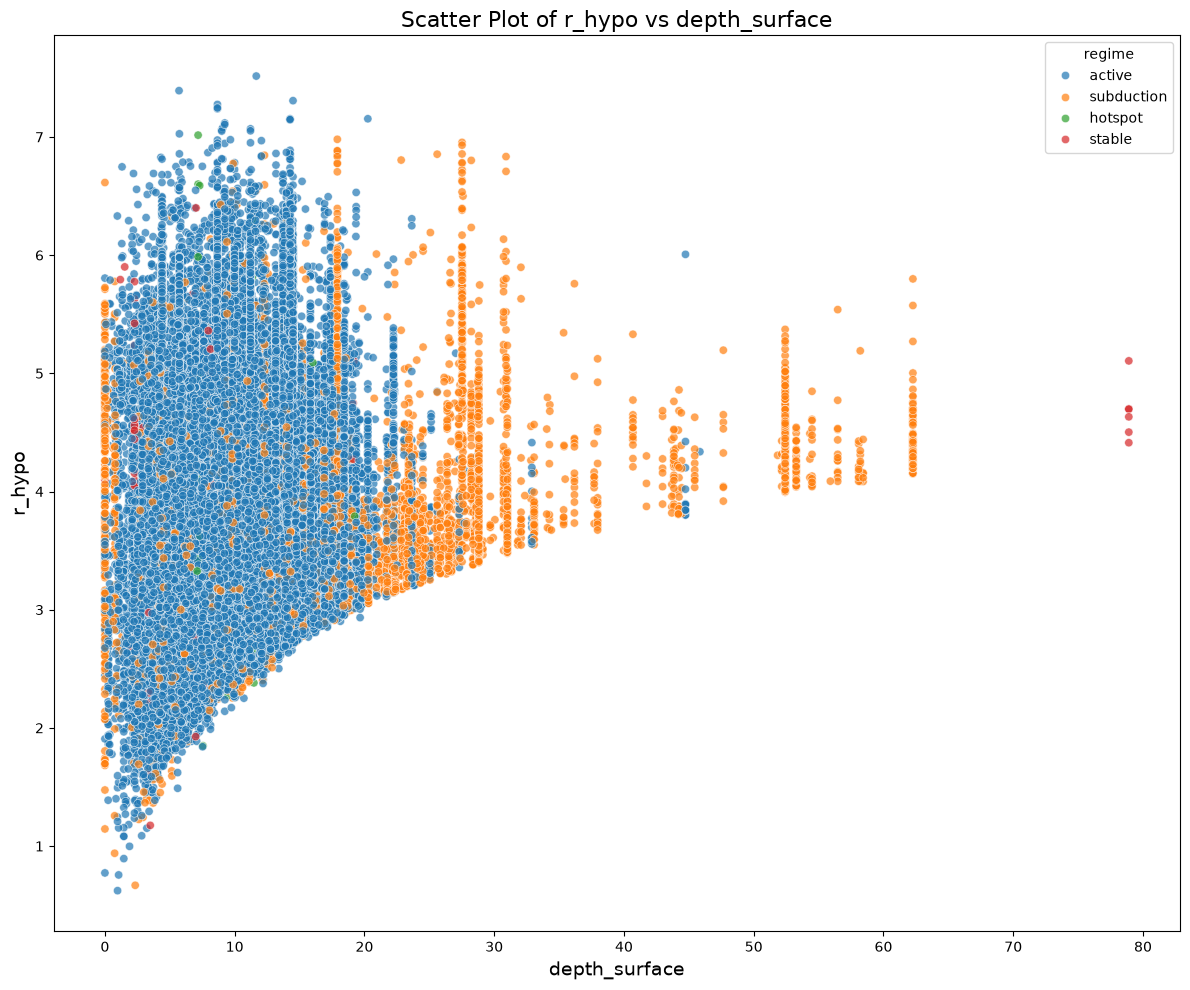

In [55]:
# Scatter Plot With the target variable (RHYPO) on the y-axis and each of the other features on the x-axis
# unquedf = df.drop_duplicates(subset=[MetadataSchema.ID.value])

logged_df = df.sample(frac=0.10, random_state=42)  # Sample 25% of the data for faster plotting
logged_df[T1ModelSchema.RHYPO.value] = np.log(logged_df[T1ModelSchema.RHYPO.value] + 1)

used_feature = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value]
target_feature = T1ModelSchema.RHYPO.value
for col in used_feature:
	plt.figure(figsize=(12, 10))
	sns.scatterplot(
		data=logged_df,
		x=col,
		y=target_feature,
		hue=T1ModelSchema.REGIME.value,
		alpha=0.7
	)
	plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
	plt.xlabel(col, fontsize=14)
	plt.ylabel(T1ModelSchema.RHYPO.value, fontsize=14)
	plt.legend(title=T1ModelSchema.REGIME.value)
	plt.tight_layout()
	plt.show()

In [60]:
from sklearn.model_selection import GroupShuffleSplit


df_sample = df.sample(frac=0.25, random_state=42)

regime_col = T1ModelSchema.REGIME.value
id_col = MetadataSchema.ID.value

active_df = df_sample[df_sample[regime_col] == "active"].copy()

active_df = active_df.drop(
    columns=[f.value for f in MetadataSchema if f != id_col]+[regime_col]
)

# 4. Perform GroupShuffleSplit directly on active_df
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(active_df, groups=active_df[id_col]))

# 5. Split using .iloc (indices now match active_df perfectly)
train_df = active_df.iloc[train_idx].drop(columns=[id_col])
test_df = active_df.iloc[test_idx].drop(columns=[id_col])

# 6. Separate X and y
target = T1ModelSchema.MMI.value

X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Train set shape: (123621, 3), (123621,)
Test set shape: (26349, 3), (26349,)


In [68]:
# Linear / Ridge Regression
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

# # Or LightGBM / HistGradientBoosting Regressor
# from sklearn.ensemble import HistGradientBoostingRegressor

# model_hgb = HistGradientBoostingRegressor(random_state=42)
# model_hgb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [69]:
model_ridge.score(X_test, y_test)

0.13211233088309204